In [2]:
import pandas as pd
from pathlib import Path
import numpy as np

INPUT_CSV = Path("../../graph_1.csv")
df = pd.read_csv(INPUT_CSV)
df["total_time_sec"] = df["pfp_time_sec"]
df[["sample_size", "total_time_sec"]]


,sample_size,total_time_sec
0,27648,7.291075
1,55296,8.545095
2,82945,10.132169
3,110593,11.727983
4,138242,13.458352
5,165890,15.324495
6,221187,19.816743
7,276484,24.504039


In [8]:
time_sec = df["pfp_time_sec"]
sample_size = df["sample_size"]
# df[["fraction", "total_time_sec"]]
stats_df = pd.DataFrame()
stats_df["linear"] = time_sec/sample_size
stats_df["nlogn"] = time_sec/(sample_size**2)

stats_df

,linear,nlogn
0,0.000264,9.538150e-09
1,0.000155,2.794663e-09
2,0.000122,1.472726e-09
3,0.000106,9.588883e-10
4,0.000097,7.042257e-10
5,0.000092,5.568596e-10
6,0.000090,4.050542e-10
7,0.000089,3.205514e-10


Linear constant: 8.86273296429432e-05
NlogN constant: 9.53814961259405e-09


/tmp/ipykernel_84778/1521580258.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  graph_df["linear"] = linear
/tmp/ipykernel_84778/1521580258.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  graph_df["nlogn"] = nlogn


<Axes: title={'center': 'PFP Time Complexity'}, xlabel='Sample Size', ylabel='Time (s)'>

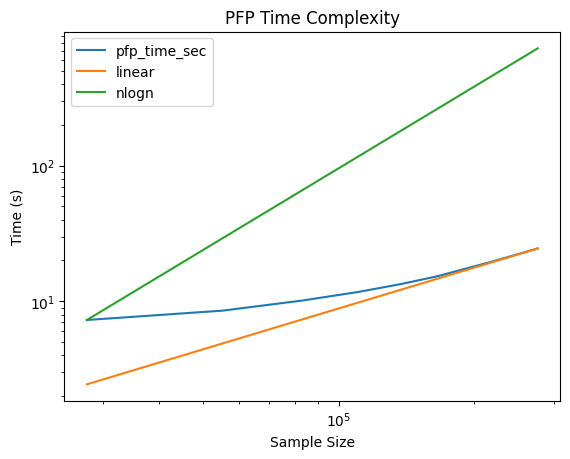

In [11]:
LINEAR_CONSTANT = stats_df["linear"].min()
NLOGN_CONSTANT = stats_df["nlogn"].max()
print(f"Linear constant: {LINEAR_CONSTANT}")
print(f"NlogN constant: {NLOGN_CONSTANT}")

linear = df.sample_size * LINEAR_CONSTANT
nlogn = (df.sample_size **2) * NLOGN_CONSTANT
graph_df = df[["sample_size", "pfp_time_sec"]]
graph_df["linear"] = linear
graph_df["nlogn"] = nlogn

graph_df.plot.line(x="sample_size", y=["pfp_time_sec", "linear", "nlogn"], title="PFP Time Complexity", xlabel="Sample Size", ylabel="Time (s)", logy=True, logx=True)
# graph_df

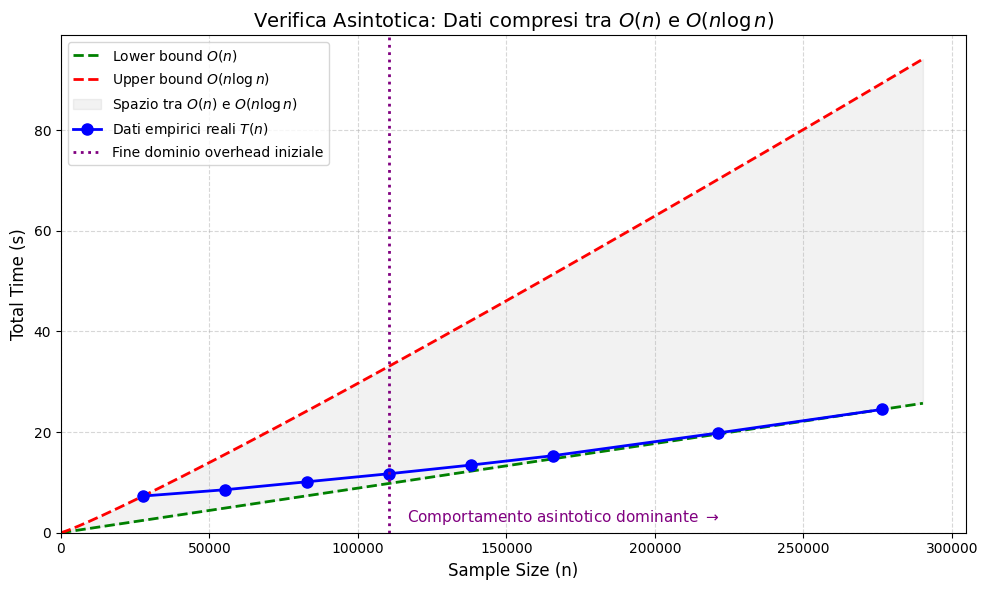

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. I tuoi dati grezzi
n_vals = np.array([27648, 55296, 82945, 110593, 138242, 165890, 221187, 276484])
T_vals = np.array([7.2910751, 8.5450953, 10.1321686, 11.7279827, 
                   13.4583516, 15.3244946, 19.8167434, 24.5040386])

# 2. Le due costanti calcolate matematicamente in modo puro (niente fitting)
c_lower = np.min(T_vals / n_vals)
c_upper = np.max(T_vals / (n_vals * np.log2(n_vals)))

# 3. Creiamo l'asse X denso partendo da un valore piccolissimo (non 0 per evitare errori di log(0))
n_dense = np.linspace(10, max(n_vals) * 1.05, 500)

bound_lower = c_lower * n_dense
bound_upper = c_upper * n_dense * np.log2(n_dense)

# 4. Disegniamo il grafico (SCALA LINEARE CLASSICA)
plt.figure(figsize=(10, 6))

# Le due curve limite
plt.plot(n_dense, bound_lower, color='green', linestyle='--', linewidth=2, 
         label=f'Lower bound $O(n)$')
plt.plot(n_dense, bound_upper, color='red', linestyle='--', linewidth=2, 
         label=f'Upper bound $O(n \\log n)$')

# Riempiamo lo spazio tra le due curve per evidenziare l'area di appartenenza
plt.fill_between(n_dense, bound_lower, bound_upper, color='gray', alpha=0.1, label="Spazio tra $O(n)$ e $O(n \\log n)$")

# I tuoi dati
plt.plot(n_vals, T_vals, marker='o', color='blue', linestyle='-', linewidth=2, 
         markersize=8, label='Dati empirici reali $T(n)$')

# --- NUOVA RIGA VERTICALE PER L'OVERHEAD ---
# Fissiamo il marcatore al 4° campione, dove i tempi iniziano a scalare proporzionalmente
punto_overhead = 110593 
plt.axvline(x=punto_overhead, color='purple', linestyle=':', linewidth=2, 
            label='Fine dominio overhead iniziale')
plt.text(punto_overhead + 6000, 3, 'Comportamento asintotico dominante $\\rightarrow$', 
         color='purple', fontsize=11, verticalalignment='center')
# -------------------------------------------

# FORZIAMO L'INIZIO DEGLI ASSI A ZERO
plt.xlim(left=0)
plt.ylim(bottom=0)

plt.xlabel('Sample Size (n)', fontsize=12)
plt.ylabel('Total Time (s)', fontsize=12)
plt.title('Verifica Asintotica: Dati compresi tra $O(n)$ e $O(n \\log n)$', fontsize=14)

plt.legend(fontsize=10, loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

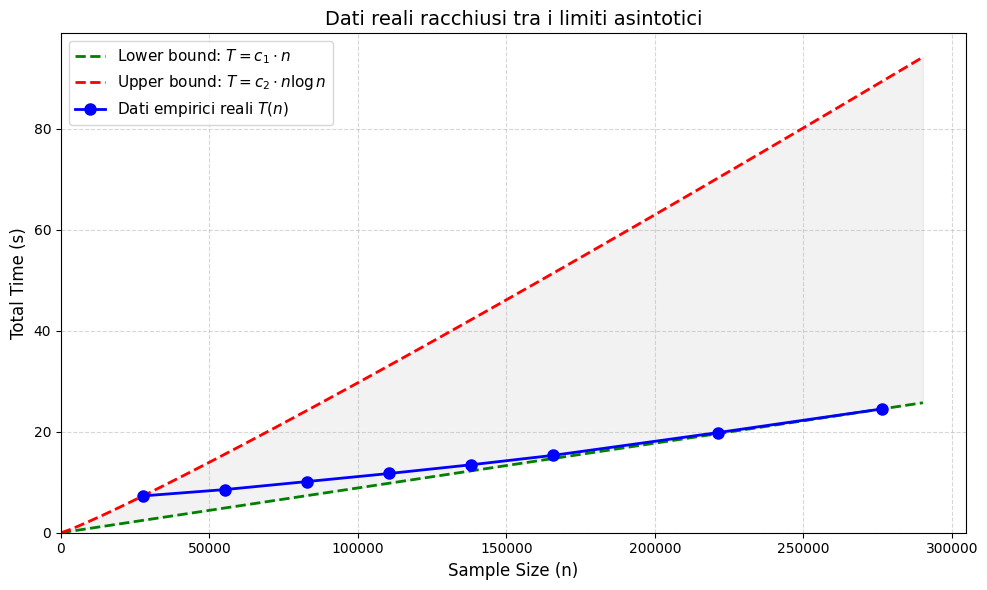

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# I tuoi dati grezzi intatti
n_vals = np.array([27648, 55296, 82945, 110593, 138242, 165890, 221187, 276484])
T_vals = np.array([7.2910751, 8.5450953, 10.1321686, 11.7279827, 
                   13.4583516, 15.3244946, 19.8167434, 24.5040386])

# Calcolo delle costanti usando rigorosamente i minimi e massimi assoluti
c_lower = np.min(T_vals / n_vals)
c_upper = np.max(T_vals / (n_vals * np.log2(n_vals)))

# Creazione delle linee da x=1 (evitiamo log(0)) fino al tuo massimo dato
n_dense = np.linspace(10, max(n_vals) * 1.05, 500)

bound_lower = c_lower * n_dense
bound_upper = c_upper * n_dense * np.log2(n_dense)

# Disegno del grafico in scala lineare
plt.figure(figsize=(10, 6))

plt.plot(n_dense, bound_lower, color='green', linestyle='--', linewidth=2, 
         label=f'Lower bound: $T = c_1 \cdot n$')
plt.plot(n_dense, bound_upper, color='red', linestyle='--', linewidth=2, 
         label=f'Upper bound: $T = c_2 \cdot n \log n$')

# Area di validità
plt.fill_between(n_dense, bound_lower, bound_upper, color='gray', alpha=0.1)

# Dati grezzi
plt.plot(n_vals, T_vals, marker='o', color='blue', linestyle='-', linewidth=2, 
         markersize=8, label='Dati empirici reali $T(n)$')

# Assi forzati a 0 per mostrare le vere pendenze
plt.xlim(left=0)
plt.ylim(bottom=0)

plt.xlabel('Sample Size (n)', fontsize=12)
plt.ylabel('Total Time (s)', fontsize=12)
plt.title('Dati reali racchiusi tra i limiti asintotici', fontsize=14)

plt.legend(fontsize=11, loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()